In [7]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# ================================================================
# Constants
# ================================================================
DATA_ROOT = "../../fiot_highway2-main/data/"
TRAIN_TXT = "../../fiot_highway2-main/train.txt"
TEST_TXT  = "../../fiot_highway2-main/test.txt"
MIN_LABEL = 4
MAX_LABEL = 8
RESIZE_TO = (64, 64)
BATCH_SIZE = 32
LR = 1e-3
MAX_EPOCHS = 8
MIN_DB = -140.0 #WARNING: based on visualzing dataset may not be the absolute min
MAX_DB =   0.0

# ================================================================
# Step 1: extract file paths within label range
# ================================================================
def struct_extract(struct, min_label, max_label):
    paths  = []
    labels = []
    for entry in struct:
        label = int(entry[1])
        if min_label <= label <= max_label:
            path = entry[0].split('/')[1].split('.')[0]
            paths.append(path)
            labels.append(label)
    return paths, labels

all_train_struct = np.loadtxt(TRAIN_TXT, dtype=str).tolist()
all_test_struct  = np.loadtxt(TEST_TXT,  dtype=str).tolist()

train_paths, train_labels = struct_extract(all_train_struct, MIN_LABEL, MAX_LABEL)
test_paths,  test_labels  = struct_extract(all_test_struct,  MIN_LABEL, MAX_LABEL)
print(len(train_labels))
print("done")

# ================================================================
# Step 2: dataset class
# NOTE: classifing 4 to 8, but 4 = 0, 5 = 1, ... ****
# ================================================================
class HighwayDataset(Dataset):
    def __init__(self, paths, labels, data_root, resize=(64,64)):
        self.paths = paths
        self.labels = labels
        self.data_root = data_root
        self.resize = resize

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        fname = self.paths[idx] + ".npy"
        arr = np.load(os.path.join(self.data_root, fname))   # shape (512,243)
        arr = np.clip(arr, MIN_DB, MAX_DB) # Clip to a fixed dB range 
        arr = (arr - MIN_DB) / (MAX_DB - MIN_DB) # Scale to [0,1] VERIFY THIS
        img = torch.from_numpy(arr.astype(np.float32))    # H x W
        img = img.unsqueeze(0)                            # 1 Input Channel (amplitude) || 1 x H x W
        img = TF.resize(img, self.resize)                 # RESIZE still 1 x h x w
        label = int(self.labels[idx]) - MIN_LABEL # **** Label shift 
        return img, label

train_ds = HighwayDataset(train_paths, train_labels, DATA_ROOT, RESIZE_TO)
test_ds  = HighwayDataset(test_paths,  test_labels, DATA_ROOT, RESIZE_TO)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4) #best number workers depends on CPU cores
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, num_workers=4) #best number workers depends on CPU cores
print("done")

1069
done
done


In [9]:
# ================================================================
# Step 3: simple CNN
# ================================================================
class CNN(pl.LightningModule):
    def __init__(self, num_classes=MAX_LABEL-MIN_LABEL+1):
        super().__init__()
        self.save_hyperparameters()
        ## WARNING: this assumes the size is 64x64, not generalized for different cases yet.
        
        ## Model:
        ## 1st Convolution, ReLu, Pooling Block
        # Convolution: (1 = input channels, 16 = output channels, kernal_size = 3x3, padding = 1 keeps spatial size the same (Shape 1x64x64 -> 16x64x64), 
        # ReLU
        # Pooling: downsamples (16x64x64 -> 16x32x32)
        ## 2nd Convolution ReLu, Pooling Block
        # Convolution: (16, 32, 32) → (32, 32, 32)
        # ReLU:
        # Pooling: (32, 32, 32) → (32, 16, 16)
        ## 3rd Convolution ReLu, Pooling Block
        # Convolution: (32, 16, 16) → (64, 16, 16)
        # ReLU:
        # Pooling: (64, 16, 16) → (64, 8, 8)
        ## Flatten: (64, 8, 8) -> single vector length 4096
        ## Linear: fully connected layers compresses 4096 learned features into 128
        # ReLU:
        ## Linear: compresses 128 into num_classes | creates logits
        
        self.model = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), 
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, num_classes)
        )

        self.loss_fn = nn.CrossEntropyLoss() #applies softmax to logits

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("train_loss", loss)
        self.log("train_acc", acc)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("test_loss", loss)
        self.log("test_acc", acc)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=LR)
print("done")
# ================================================================
# Step 4: train and test
# ================================================================
logger = CSVLogger("logs", name="cnn_highway")

model = CNN()
trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    accelerator="auto"
)
trainer.fit(model, train_loader) #train
trainer.test(model, test_loader) #test
print("done")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type             | Params | Mode 
-----------------------------------------------------
0 | model   | Sequential       | 548 K  | train
1 | loss_fn | CrossEntropyLoss | 0      | train
-----------------------------------------------------
548 K     Trainable params
0         Non-trainable params
548 K     Total params
2.193     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


done


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=8` reached.
/usr/local/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8713235259056091     │
│         test_loss         │    0.35573339462280273    │
└───────────────────────────┴───────────────────────────┘

done


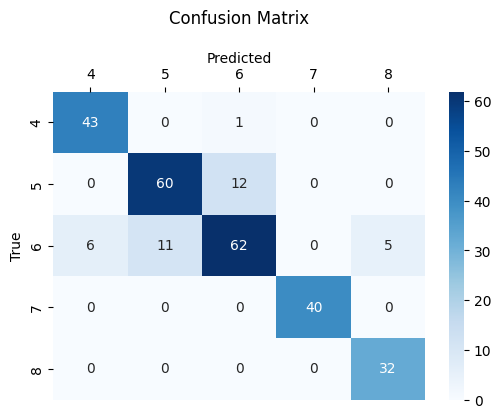

done


In [11]:
# ================================================================
# Step 5: confusion matrix
# ================================================================
y_true = []
y_pred = []
model.eval() #put model in output mode
with torch.no_grad(): #saves memory as no gradients stored?
    for x, y in test_loader:
        logits = model(x) #runs the model with the input x, to get raw predicitons (running the forward step in CNN)
        preds = logits.argmax(1) #preds gets model predicitons from raw logits
        y_true.extend(y.cpu().numpy()) #y has the know true labels
        y_pred.extend(preds.cpu().numpy()) 

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(range(MIN_LABEL, MAX_LABEL+1)),
            yticklabels=list(range(MIN_LABEL, MAX_LABEL+1)))

plt.gca().xaxis.set_label_position('top')  # put x-label on top
plt.gca().xaxis.tick_top()                 # put x-ticks on top

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix", pad=20)
plt.show()
print("done")

In [ ]:
# Questions: does runnning more epochs result in better results, what is train loss I understand the accuracy